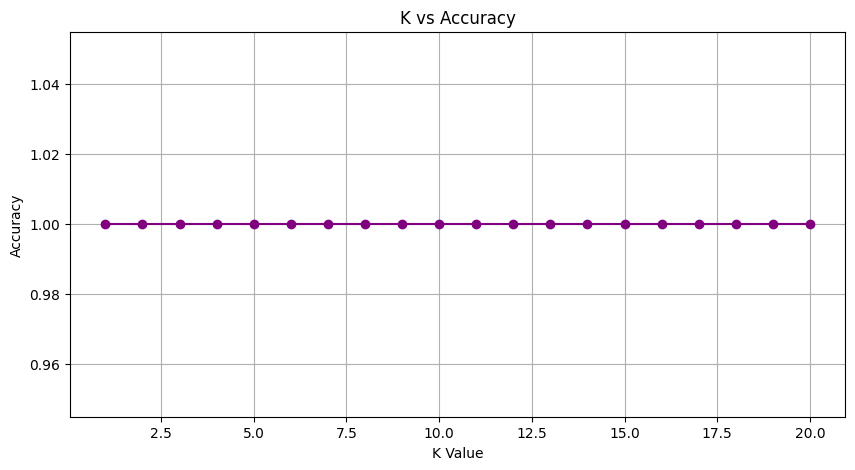

Best K: 1
Best Accuracy: 1.0000


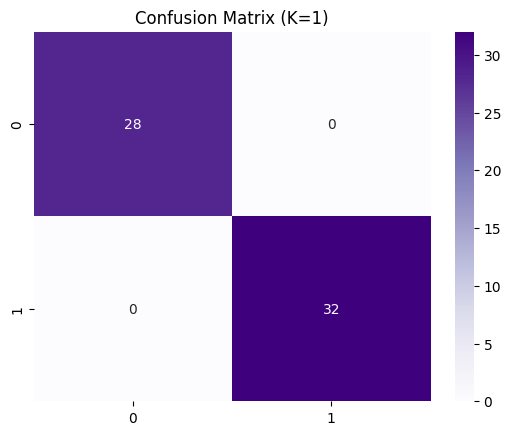

In [ ]:
# Learn KNN with a simple dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

np.random.seed(42)
X = np.random.rand(300, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

accuracies = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), accuracies, marker='o', color='purple')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.grid(True)
plt.show()

best_k = np.argmax(accuracies) + 1
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

print(f"Best K: {best_k}")
print(f"Best Accuracy: {max(accuracies):.4f}")

cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()